# 02. Entendimiento de los datos (EDA)

## 1. Objetivo
Comprender la estructura, calidad y comportamiento del dataset `raw.csv` para identificar patrones iniciales, problemas de calidad de datos y relaciones potenciales entre las variables explicativas y la variable objetivo `Depression`, como base para la fase de preparación de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

df = pd.read_csv("../data/raw/raw.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
print("Dimensiones:", df.shape)
display(pd.DataFrame({"dtype": df.dtypes, "nulos": df.isnull().sum(), "n_unicos": df.nunique()}))
df.info()
df.describe(include="all").T

Dimensiones: (27901, 18)


,dtype,nulos,n_unicos
id,int64,0,27901
Gender,object,0,2
Age,float64,0,34
City,object,0,52
Profession,object,0,14
Academic Pressure,float64,0,6
Work Pressure,float64,0,3
CGPA,float64,0,332
Study Satisfaction,float64,0,6
Job Satisfaction,float64,0,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,27901.0,NaN,NaN,NaN,70442.149421,40641.175216,2.0,35039.0,70684.0,105818.0,140699.0
Gender,27901,2,Male,15547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,27901.0,NaN,NaN,NaN,25.8223,4.905687,18.0,21.0,25.0,30.0,59.0
City,27901,52,Kalyan,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,27901,14,Student,27870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Pressure,27901.0,NaN,NaN,NaN,3.141214,1.381465,0.0,2.0,3.0,4.0,5.0
Work Pressure,27901.0,NaN,NaN,NaN,0.00043,0.043992,0.0,0.0,0.0,0.0,5.0
CGPA,27901.0,NaN,NaN,NaN,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,NaN,NaN,NaN,2.943837,1.361148,0.0,2.0,3.0,4.0,5.0
Job Satisfaction,27901.0,NaN,NaN,NaN,0.000681,0.044394,0.0,0.0,0.0,0.0,4.0


In [4]:
diccionario = pd.DataFrame({
    "variable": df.columns,
    "rol": ["id" if c.lower()=="id" else "objetivo" if c=="Depression" else "predictora" for c in df.columns]
})
diccionario

,variable,rol
0,id,id
1,Gender,predictora
2,Age,predictora
3,City,predictora
4,Profession,predictora
5,Academic Pressure,predictora
6,Work Pressure,predictora
7,CGPA,predictora
8,Study Satisfaction,predictora
9,Job Satisfaction,predictora


Desde un punto de vista inicial observamos que estas variables pueden ser más importantes para la predicción de nuestro modelo:
- Academic Pressure

- CGPA

- Sleep Duration

- Dietary Habits

- Financial Stress

- Family History of Mental Illness

- Have you ever had suicidal thoughts ? (sensible)

## 2. Calidad de datos

In [5]:
# Nulos
nulos = df.isnull().sum().sort_values(ascending=False)
display(nulos[nulos > 0])

# Duplicados
print("Duplicados exactos:", df.duplicated().sum())

# Valores únicos por columna
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].astype(str).value_counts(dropna=False).head(10))

Series([], dtype: int64)

Duplicados exactos: 0

--- id ---
id
140699    1
2         1
8         1
26        1
30        1
32        1
33        1
52        1
56        1
59        1
Name: count, dtype: int64

--- Gender ---
Gender
Male      15547
Female    12354
Name: count, dtype: int64

--- Age ---
Age
24.0    2258
20.0    2237
28.0    2133
29.0    1950
33.0    1893
25.0    1784
21.0    1726
23.0    1645
18.0    1587
19.0    1560
Name: count, dtype: int64

--- City ---
City
Kalyan         1570
Srinagar       1372
Hyderabad      1340
Vasai-Virar    1290
Lucknow        1155
Thane          1139
Ludhiana       1111
Agra           1094
Surat          1078
Kolkata        1066
Name: count, dtype: int64

--- Profession ---
Profession
Student               27870
Architect                 8
Teacher                   6
'Digital Marketer'        3
Chef                      2
'Content Writer'          2
Pharmacist                2
Doctor                    2
'UX/UI Designer'          1
'Civil Engineer'          1
Name: c

Observamos que existen registros con comillas que pueden entorpecer el análisis más adelante, también hay unos registros en "Financial Stress" que son "?", además hay registros en "Profession" que no son de estudiantes.

## 3. Variable objetivo

,conteo,proporcion
Depression,,
1,16336,0.5855
0,11565,0.4145


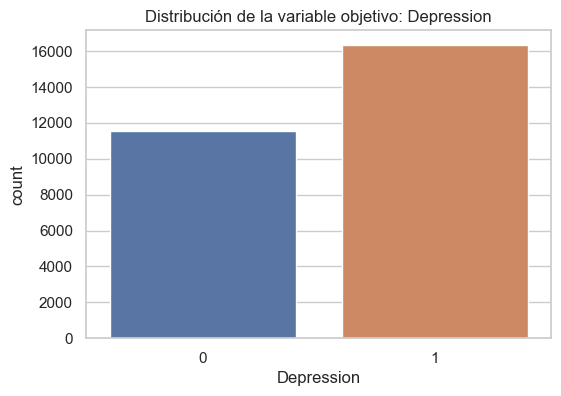

In [6]:
target_dist = df["Depression"].value_counts(dropna=False)
target_prop = df["Depression"].value_counts(normalize=True, dropna=False)

display(pd.DataFrame({
    "conteo": target_dist,
    "proporcion": target_prop.round(4)
}))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Depression")
plt.title("Distribución de la variable objetivo: Depression")
plt.show()

Aquí podemos observar que la proporción de distribución de nuestra variable objetivo no esta tan desbalanceada

## 4. Análisis univariado

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Depression']
Categóricas: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']


c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


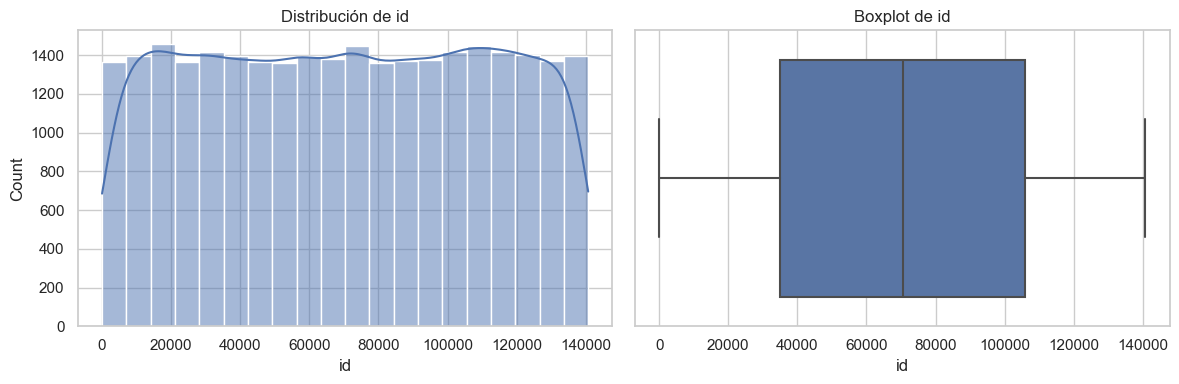

c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


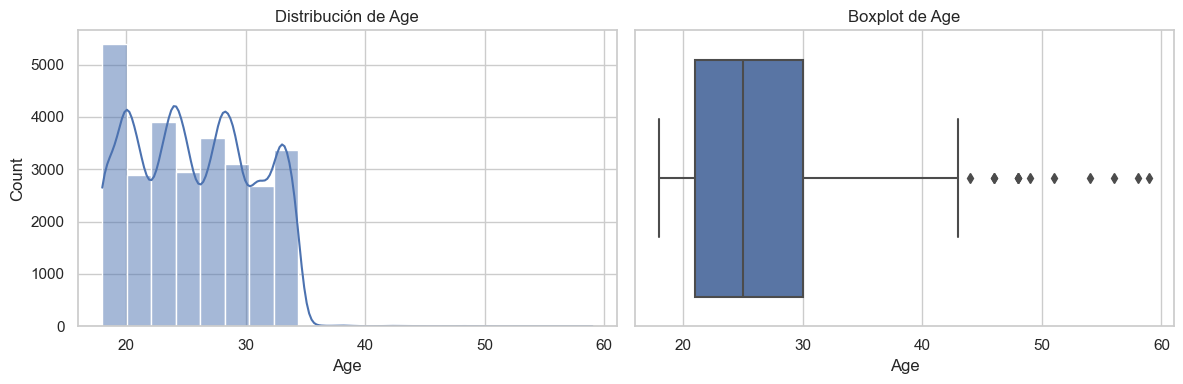

c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


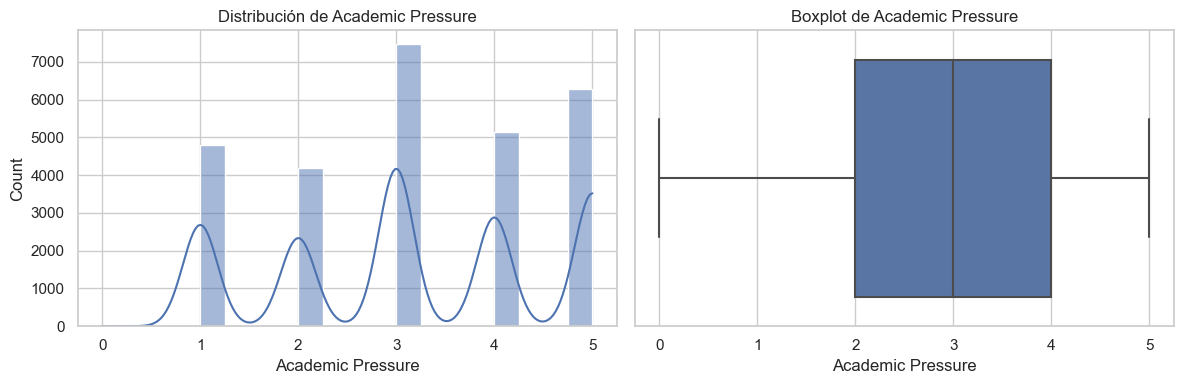

c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


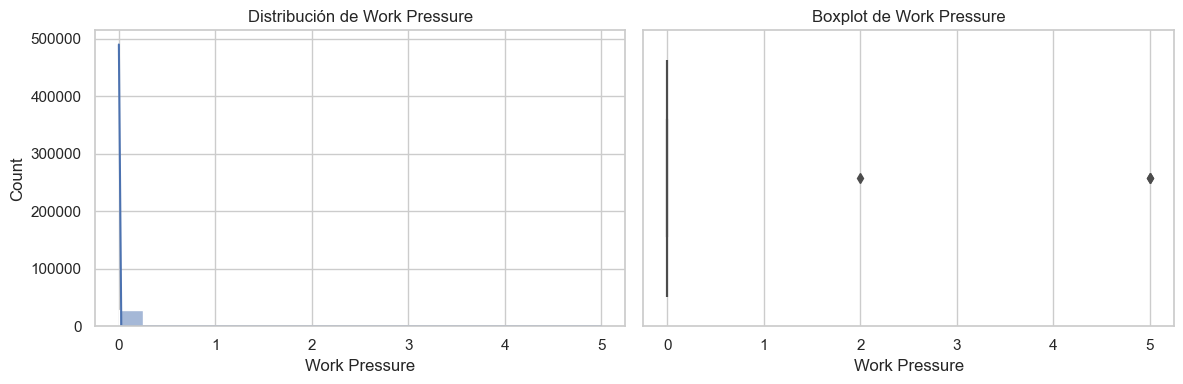

c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


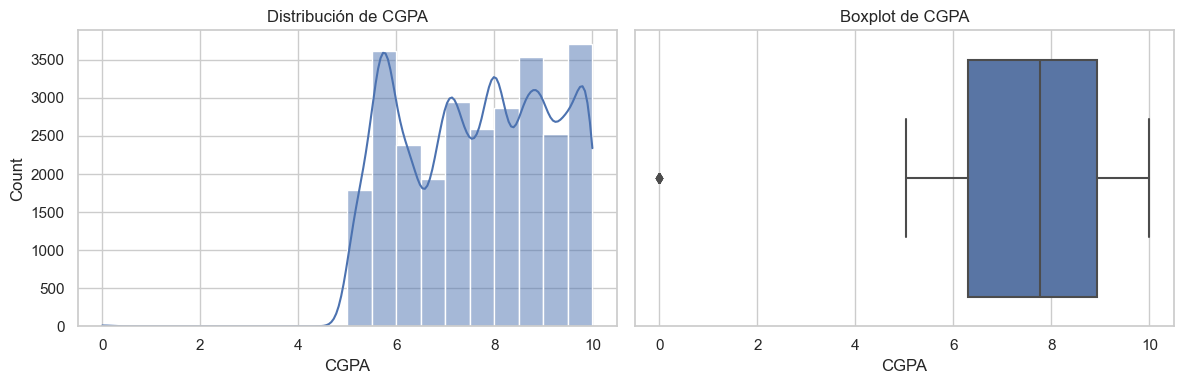

c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


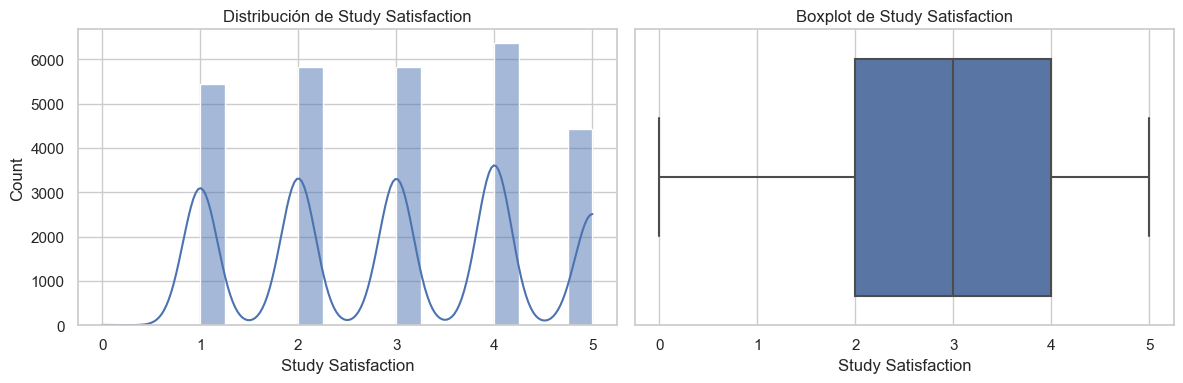

c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


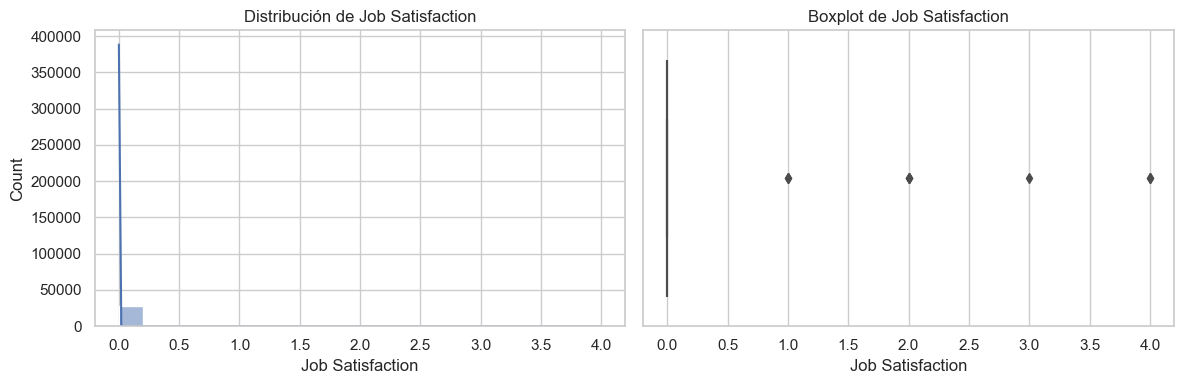

c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


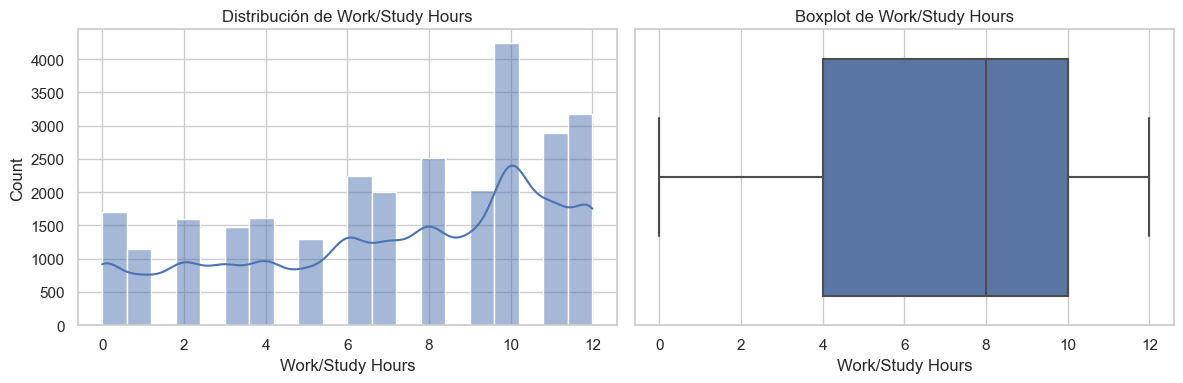

c:\Users\juanr\anaconda4\envs\analitica\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


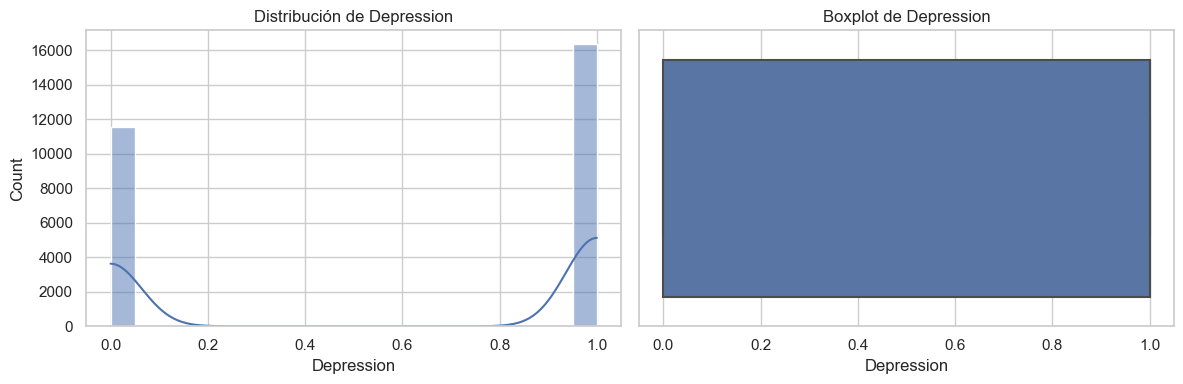

In [8]:
for col in num_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribución de {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")

    plt.tight_layout()
    plt.show()

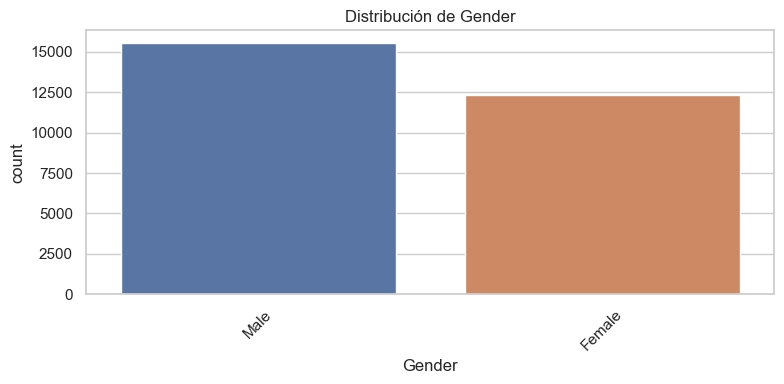

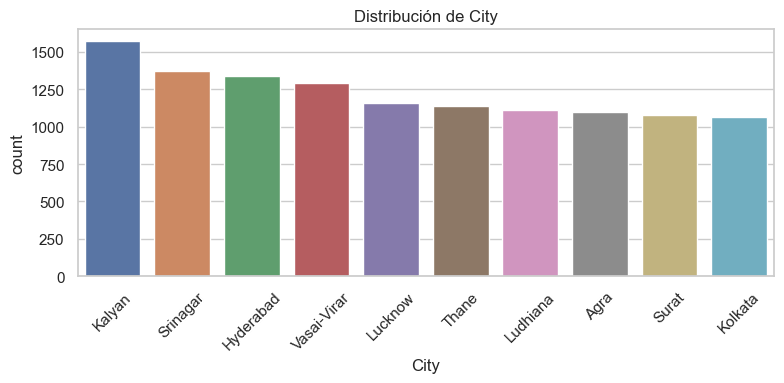

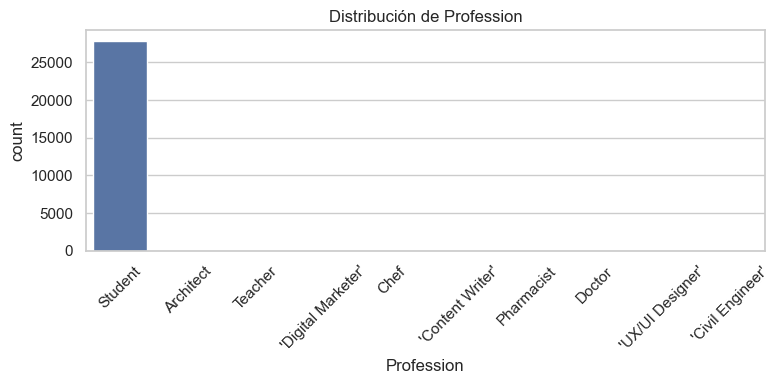

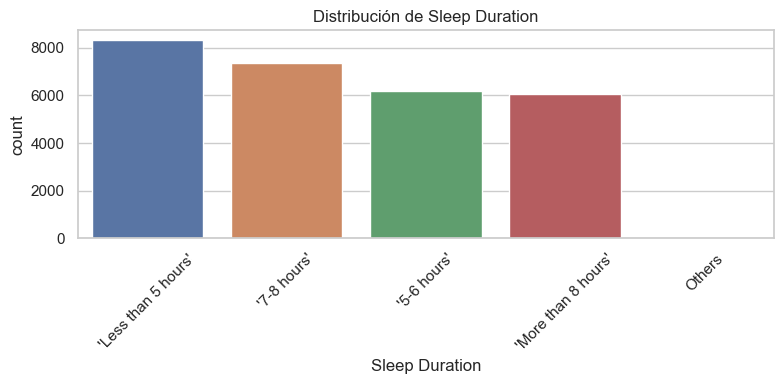

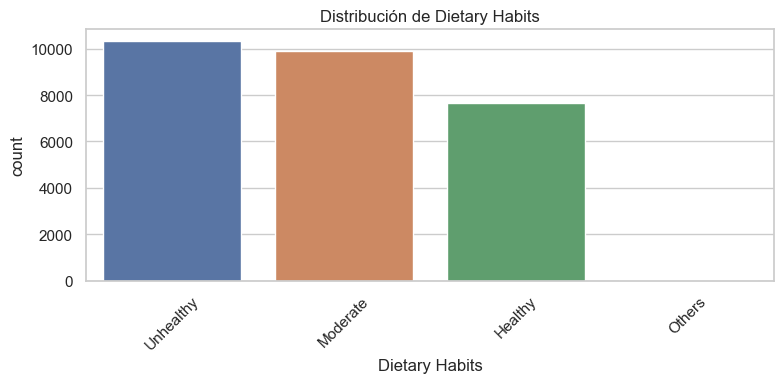

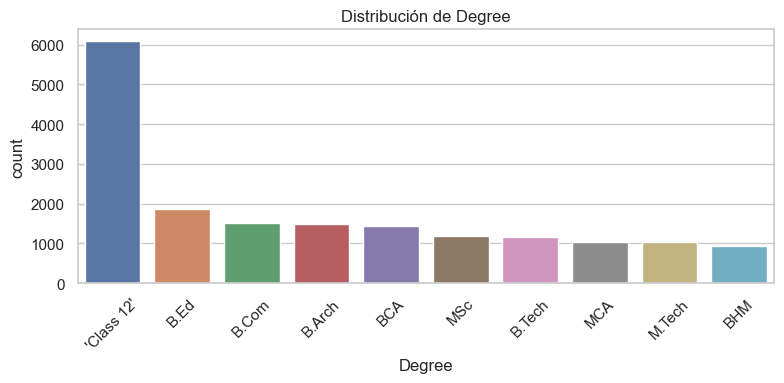

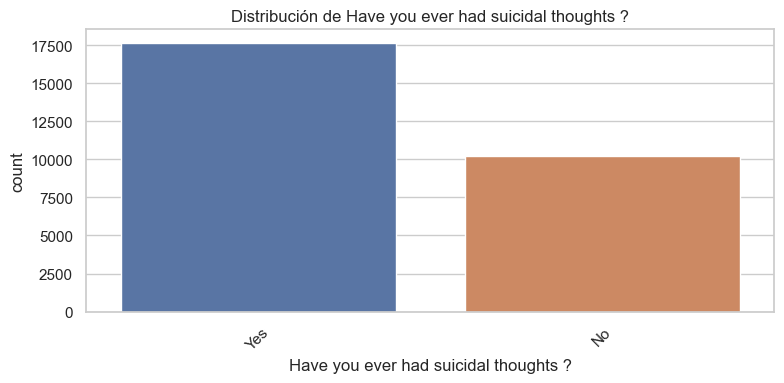

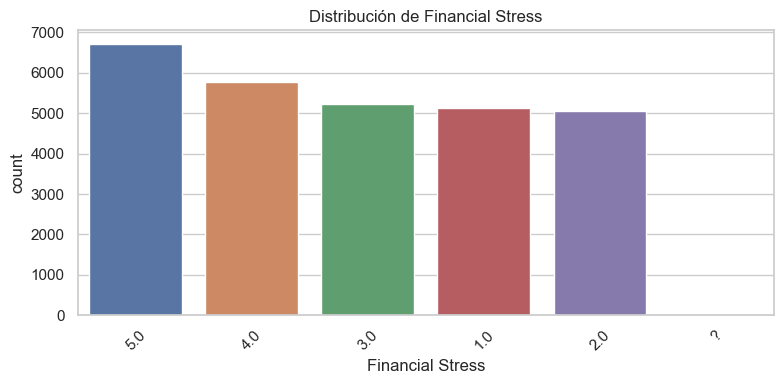

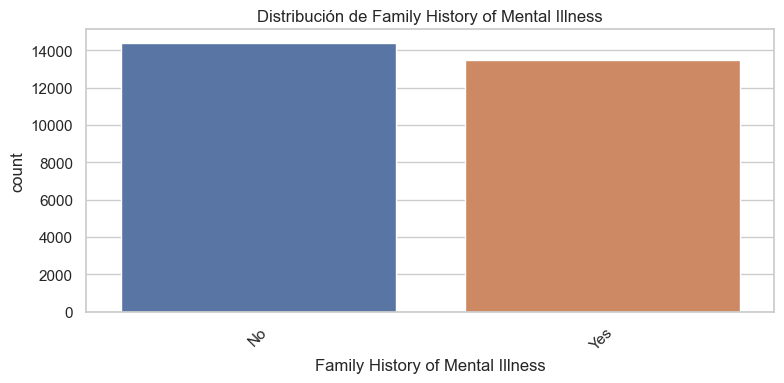

In [9]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    order = df[col].astype(str).value_counts().index[:10]
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Existen algunas variables con desbalanceo por lo que deben tratarse antes de comenzar el proceso de análisis.

## 5. Análisis bivariado de variable objetivo

### númericas vs variable objetivo

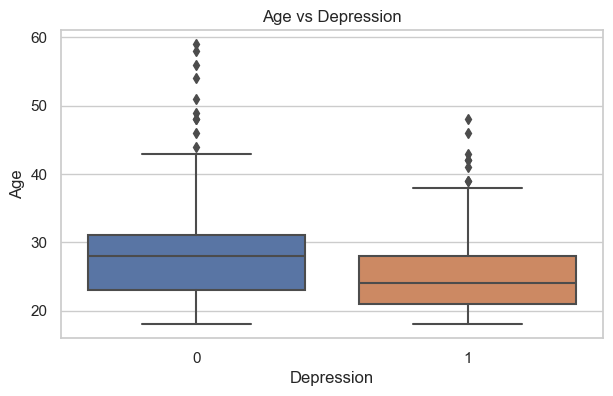

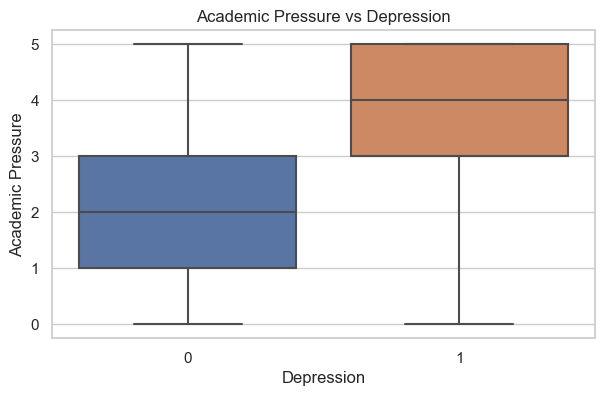

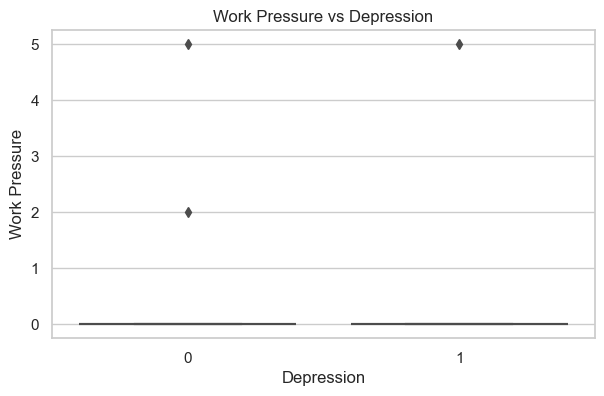

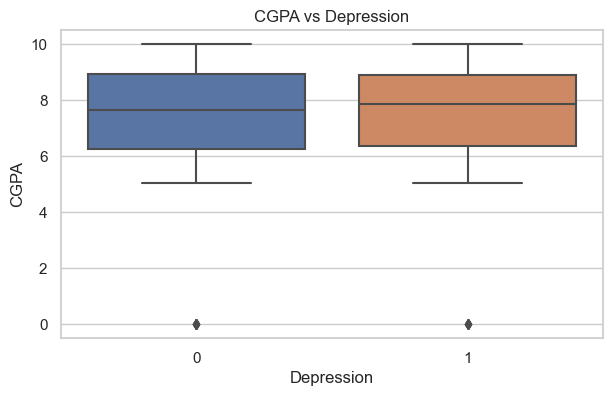

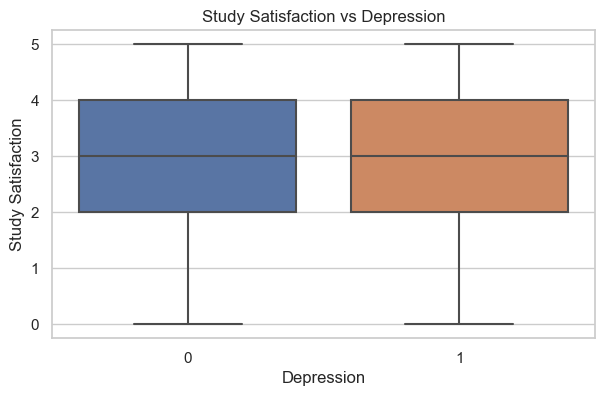

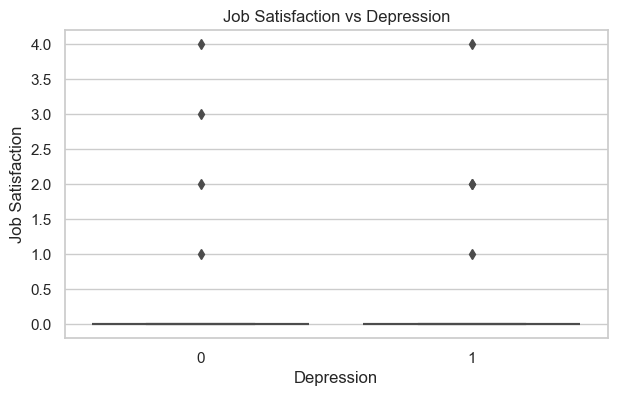

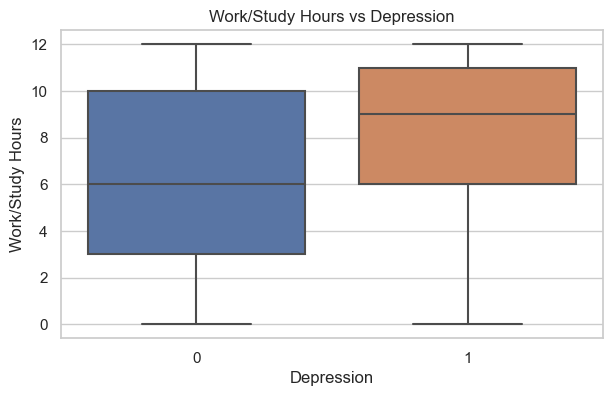

In [10]:
predictoras_num = [c for c in num_cols if c not in ["Depression", "id"]]

for col in predictoras_num:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="Depression", y=col)
    plt.title(f"{col} vs Depression")
    plt.show()

### Categóricas vs variable objetivo

Depression,0,1
Gender,,
Female,41.55,58.45
Male,41.37,58.63


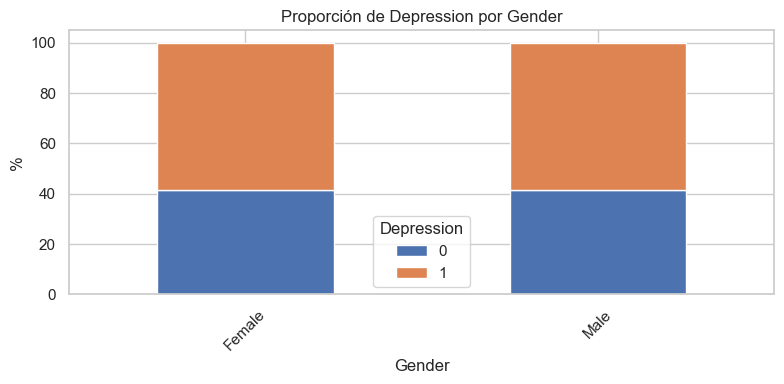

Depression,0,1
City,,
'Less Delhi',100.00,0.00
'Less than 5 Kalyan',100.00,0.00
3.0,0.00,100.00
Agra,46.53,53.47
Ahmedabad,32.70,67.30
Bangalore,39.11,60.89
Bhavna,0.00,100.00
Bhopal,38.01,61.99
Chennai,40.34,59.66


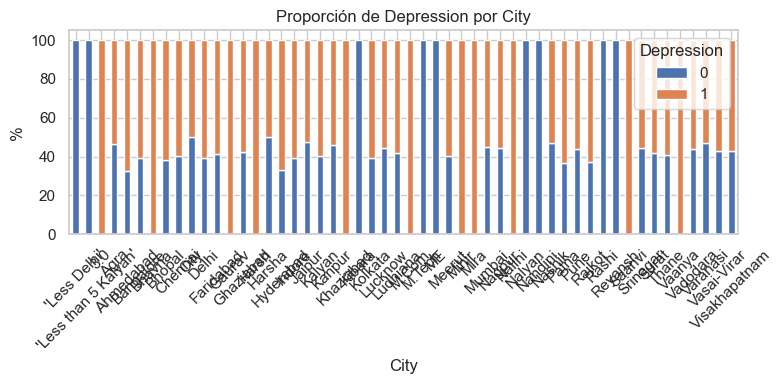

Depression,0,1
Profession,,
'Civil Engineer',0.00,100.00
'Content Writer',0.00,100.00
'Digital Marketer',33.33,66.67
'Educational Consultant',0.00,100.00
'UX/UI Designer',0.00,100.00
Architect,12.50,87.50
Chef,0.00,100.00
Doctor,0.00,100.00
Entrepreneur,0.00,100.00


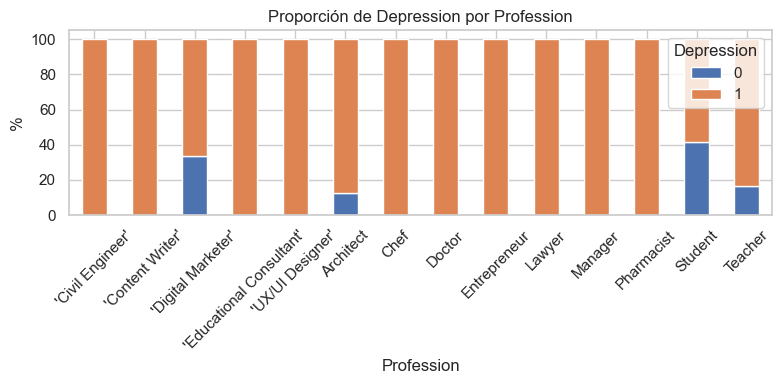

Depression,0,1
Sleep Duration,,
'5-6 hours',43.12,56.88
'7-8 hours',40.50,59.50
'Less than 5 hours',35.49,64.51
'More than 8 hours',49.07,50.93
Others,50.00,50.00


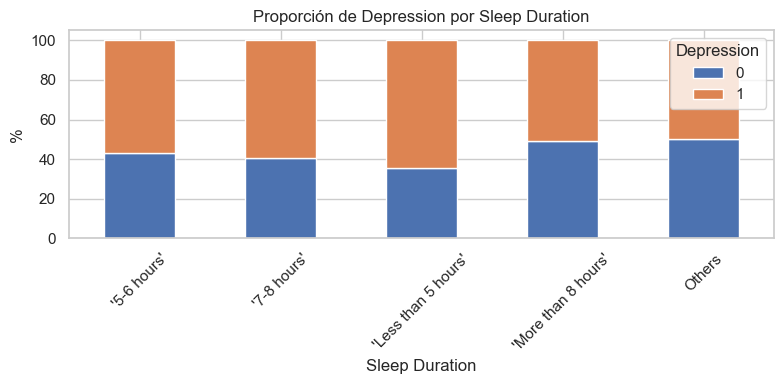

Depression,0,1
Dietary Habits,,
Healthy,54.61,45.39
Moderate,43.98,56.02
Others,33.33,66.67
Unhealthy,29.27,70.73


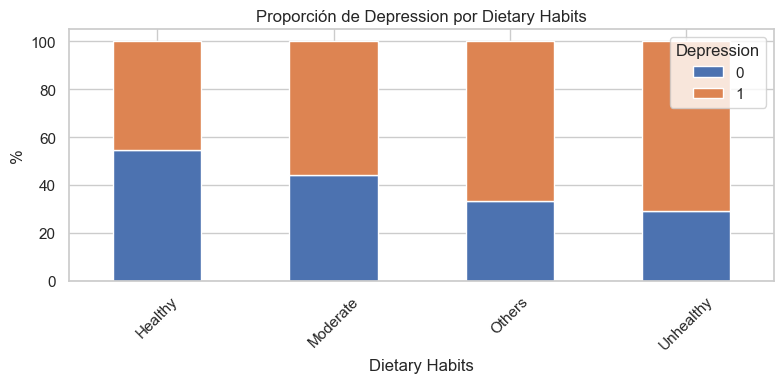

Depression,0,1
Degree,,
'Class 12',29.23,70.77
B.Arch,41.07,58.93
B.Com,43.36,56.64
B.Ed,45.31,54.69
B.Pharm,47.16,52.84
B.Tech,43.14,56.86
BA,46.50,53.50
BBA,41.52,58.48
BCA,42.85,57.15


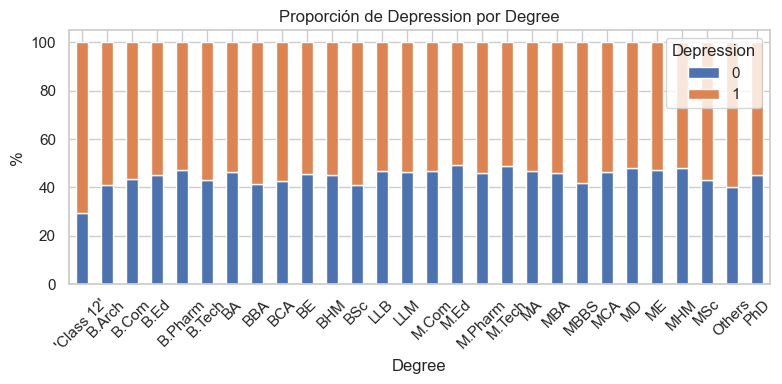

Depression,0,1
Have you ever had suicidal thoughts ?,,
No,76.78,23.22
Yes,20.95,79.05


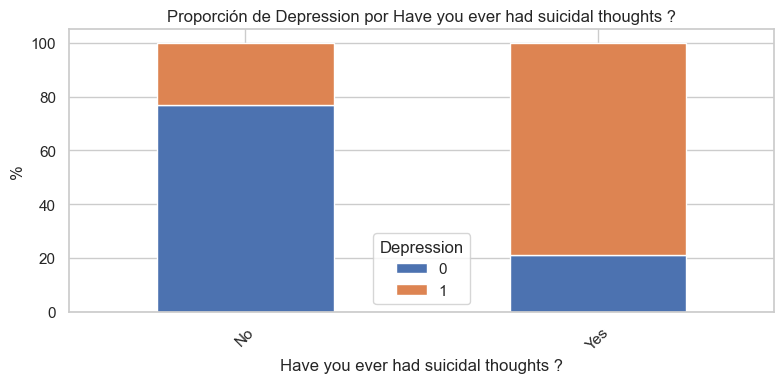

Depression,0,1
Financial Stress,,
1.0,68.13,31.87
2.0,57.02,42.98
3.0,41.06,58.94
4.0,30.91,69.09
5.0,18.72,81.28
?,66.67,33.33


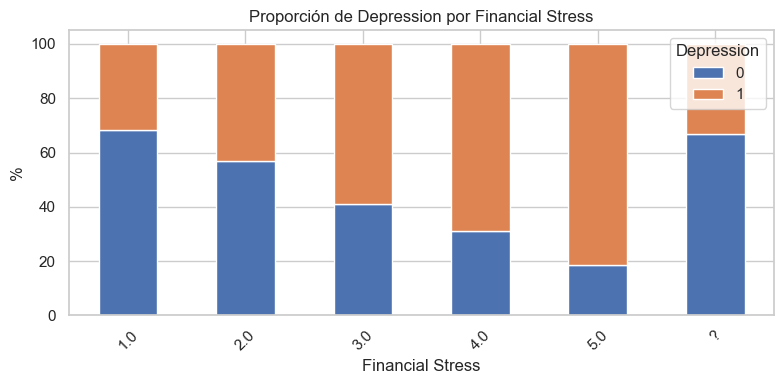

Depression,0,1
Family History of Mental Illness,,
No,44.00,56.00
Yes,38.73,61.27


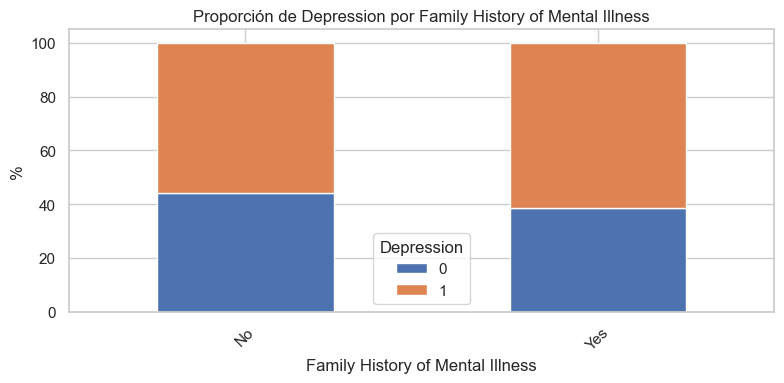

In [12]:
for col in cat_cols:
    tabla = pd.crosstab(df[col], df["Depression"], normalize="index") * 100
    display(tabla.round(2))

    tabla.plot(kind="bar", stacked=True, figsize=(8,4))
    plt.title(f"Proporción de Depression por {col}")
    plt.ylabel("%")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 6. Correlaciones

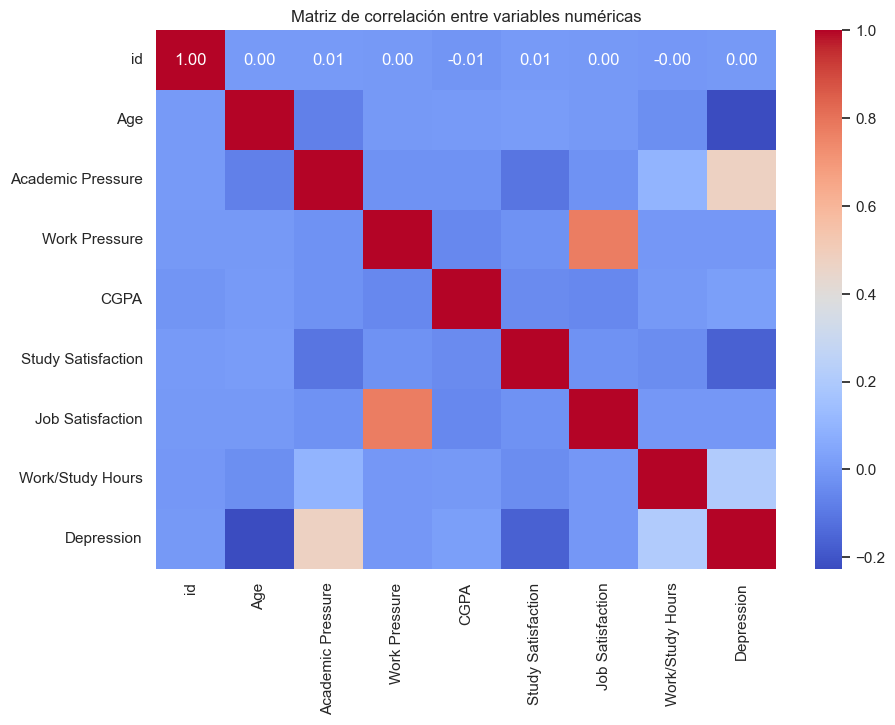

In [13]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

Se puede observar que existe una ligera correlación entre "Job Satisfaction" y "Work Pressure" debido a que ambas tienen la mayoría de registros en 0, además también tiene relación "Depression" y "Academic Pressure".

## 7. Detección de Outliers

In [14]:
def detectar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return (serie < lim_inf) | (serie > lim_sup)

outliers_resumen = []
for col in predictoras_num:
    mask = detectar_outliers_iqr(df[col].dropna())
    outliers_resumen.append({
        "variable": col,
        "n_outliers": int(mask.sum()),
        "porcentaje": round(mask.mean() * 100, 2)
    })

outliers_df = pd.DataFrame(outliers_resumen).sort_values("porcentaje", ascending=False)
display(outliers_df)

,variable,n_outliers,porcentaje
0,Age,12,0.04
5,Job Satisfaction,8,0.03
3,CGPA,9,0.03
2,Work Pressure,3,0.01
1,Academic Pressure,0,0.00
4,Study Satisfaction,0,0.00
6,Work/Study Hours,0,0.00


Existen pocos outliers por lo que podemos optar por realizar imputaciones con la mediana, pues con respecto a la media la mediana es mas resistente a valores extremos y sumado a ello al estar tratando con un dataset enfocado a la implementación de estrategias y el analisis de factores que influyen en casos depresivos, consideramos prudente que se mantengan los datos y en lugar de borrarlos se ajusten a un valor mas toleable que se ajuste mejor a las estrategias a implementar.

## 8. Hipótesis iniciales

A partir de la revisión inicial del dataset, se identificaron varios aspectos relevantes de calidad y estructura de los datos. En primer lugar, la variable Financial Stress presenta al menos 3 registros con el valor "?", lo que indica la existencia de valores inconsistentes o posiblemente faltantes codificados de forma no estándar. Esto sugiere que en la fase de preparación será necesario homologar este tipo de registros antes de cualquier modelado.

También se observó presencia de comillas dentro de valores de variables categóricas como Degree, Sleep Duration y Profession. Este hallazgo apunta a posibles problemas de limpieza o formato en la importación del archivo, los cuales podrían generar categorías duplicadas aparentes o afectar procesos posteriores de codificación.

En las variables numéricas Work Pressure y Job Satisfaction, los boxplots muestran una fuerte concentración en el valor 0, representando aproximadamente el 99% de los registros. Esto sugiere una muy baja variabilidad en estas variables y abre la hipótesis de que podrían estar asociadas a una característica estructural del dataset, por ejemplo, que la mayoría de los registros correspondan a estudiantes sin actividad laboral formal. En consecuencia, estas variables podrían tener baja capacidad explicativa o requerir una interpretación especial antes de conservarlas en el modelado.

En las variables categóricas, Profession muestra un claro predominio de la categoría Student, lo que refuerza la idea de que la población analizada está altamente concentrada en estudiantes y que dicha variable podría aportar poca información discriminante si casi no presenta variación. De forma similar, en Degree se observa una categoría con más de 6000 registros, mientras las demás se encuentran bastante por debajo, con menos de 2000 aproximadamente. Esto evidencia un desbalance importante entre categorías y sugiere que podría ser necesario agrupar niveles poco frecuentes o revisar si algunas categorías representan realmente la misma información con distinto formato.

Con base en estas observaciones, se plantean las siguientes hipótesis iniciales:

La calidad de los datos puede estar afectada por valores inconsistentes y problemas de formato en variables categóricas, por lo que una limpieza adecuada podría mejorar significativamente la interpretabilidad del análisis.

Work Pressure y Job Satisfaction podrían tener baja relevancia predictiva debido a su escasa variabilidad y alta concentración en cero.

Profession posiblemente no sea una variable muy informativa si la mayoría de observaciones pertenecen a la categoría Student.

El desbalance en Degree podría influir en el análisis bivariado y en el modelado, por lo que será importante revisar si conviene agrupar categorías de baja frecuencia.

Antes de entrenar modelos, será indispensable estandarizar categorías, tratar valores atípicos de formato y verificar qué variables realmente aportan poder explicativo frente a la variable objetivo Depression.

## 9. Conclusiones

- Se identificó la estructura general del dataset y la naturaleza de las variables.
- Se revisó la calidad de datos: nulos, duplicados, tipos y consistencia de categorías.
- Se analizaron distribuciones univariadas y relaciones bivariadas con `Depression`.
- Se detectaron variables con posible mayor asociación con la variable objetivo.
- Se identificaron necesidades para la siguiente fase: limpieza de nombres, transformación de variables categóricas, posible tratamiento de outliers y estrategia de codificación.